# Notebook 3 — RAG e Análise de Erros

Este notebook cobre 2 partes:

1. **RAG** — indexação dos editais no ChromaDB e busca semântica com o Gemini
2. **Análise de erros** — identificação e categorização de falhas observadas no projeto
3. **Estimativa de custo** — A estimativa de custos foi realizada no Notebook 2

## 1. Imports

In [1]:
import os
import re
import sys
import json
import time
import requests
import chromadb
import numpy              as np
import pandas             as pd
import matplotlib.pyplot  as plt

from pathlib                 import Path
from dotenv                  import load_dotenv
from openai                  import OpenAI 
from pydantic                import ValidationError
from sentence_transformers   import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import ConfusionMatrixDisplay, classification_report

# garante que o src/ do projeto está no path para importar o schema
sys.path.insert(0, str(Path("..").resolve()))
from src.schema import EditalClassificado



/Users/tiagoleite/Desktop/projeto_nlp/.venv/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


# 2. Funções

In [ ]:
#def coletarEditaisAbertos(limite=100):
#    """
#    Busca editais com propostas ainda abertas na API do PNCP.
#    Gera embeddings e indexa no ChromaDB na coleção editais_abertos.
#    Sempre limpa a coleção antes de indexar (dados sempre frescos).
#    """
#
#    URL = "https://pncp.gov.br/api/consulta/v1/contratacoes/proposta"
#
#    print("Coletando editais abertos da API...")
#
#    editais = []
#    pagina  = 1
#
#    while len(editais) < limite:
#        try:
#            resposta = requests.get(
#                URL,
#                params={"pagina": pagina, "tamanhoPagina": 50},
#                timeout=10
#            )
#
#            if resposta.status_code == 429:
#                print("Rate limit. Aguardando 5s...")
#                time.sleep(5)
#                continue
#
#            if resposta.status_code != 200:
#                print(f"Erro HTTP {resposta.status_code}. Encerrando.")
#                break
#
#            dados    = resposta.json()
#            registros = dados.get("data", [])
#
#            if not registros:
#                break
#
#            editais.extend(registros)
#            total_pag = dados.get("totalPaginas", 1)
#            print(f"  Página {pagina}/{total_pag} — {len(registros)} editais")
#
#            if pagina >= total_pag:
#                break
#
#            pagina += 1
#            time.sleep(1.5)
#
#        except Exception as e:
#            print(f"Erro na coleta: {e}")
#            break
#
#    if not editais:
#        print("Nenhum edital aberto encontrado.")
#        return
#
#    # monta os textos para embedding
#    textos = [e.get("objetoCompra", "") or "" for e in editais]
#
#    print(f"\nGerando embeddings para {len(textos)} editais abertos...")
#    embeddings = modeloEmbedding.encode(textos, show_progress_bar=True)
#
#    # limpa a coleção antes de reinserir (garante dados sempre atuais)
#    colecaoAbertos.delete(ids=colecaoAbertos.get()["ids"])
#
#    ids        = [f"aberto_{i}" for i in range(len(editais))]
#    documentos = textos
#    metadados  = []
#
#    for e in editais:
#        unidade = e.get("unidadeOrgao", {}) or {}
#        metadados.append({
#            "modalidade":     str(e.get("modalidadeNome", "") or ""),
#            "uf":             str(unidade.get("ufSigla", "") or ""),
#            "orgao":          str(unidade.get("nomeUnidade", "") or ""),
#            "valor_estimado": float(e["valorTotalEstimado"])
#                              if e.get("valorTotalEstimado") else 0.0,
#        })
#
#    colecaoAbertos.add(
#        ids=ids,
#        embeddings=embeddings.tolist(),
#        documents=documentos,
#        metadatas=metadados
#    )
#
#    print(f"Indexados {colecaoAbertos.count()} editais abertos na coleção.")

In [2]:
def buscarEditaisSimilares(pergunta, colecao, n_resultados=5):
    """
    Gera embedding da pergunta e busca os editais mais similares no ChromaDB.
    Retorna lista com texto e metadados de cada resultado.
    """

    embedding_pergunta = modeloEmbedding.encode([pergunta])[0].tolist()

    resultados = colecao.query(
        query_embeddings=[embedding_pergunta],
        n_results=n_resultados,
        include=["documents", "metadatas", "distances"]
    )

    editais_encontrados = []

    for i in range(len(resultados["documents"][0])):
        editais_encontrados.append({
            "texto":     resultados["documents"][0][i],
            "metadados": resultados["metadatas"][0][i],
            "distancia": round(resultados["distances"][0][i], 4)
        })

    return editais_encontrados

In [3]:
def responderComRAG(pergunta, colecao):
    """
    Recupera editais relevantes e usa o Groq para gerar uma resposta
    fundamentada nesses editais.
    Retorna a resposta em texto e os editais usados como fonte.
    """

    editais = buscarEditaisSimilares(pergunta, colecao, n_resultados=5)

    # monta o contexto com os editais recuperados
    contexto = ""
    for i, e in enumerate(editais, 1):
        meta = e["metadados"]
        contexto += (
            f"\n--- Edital {i} ---\n"
            f"Texto: {e['texto']}\n"
            f"Modalidade: {meta.get('modalidade', 'não informado')}\n"
            f"UF: {meta.get('uf', 'não informado')}\n"
            f"Órgão: {meta.get('orgao', 'não informado')}\n"
            f"Valor estimado: R$ {meta.get('valor_estimado', 0):,.2f}\n"
        )

    prompt = (
        "Você é um assistente especializado em licitações públicas brasileiras.\n"
        "Com base SOMENTE nos editais abaixo, responda à pergunta do usuário.\n"
        "Se os editais não tiverem a informação, diga que não encontrou.\n\n"
        f"PERGUNTA: {pergunta}\n\n"
        f"EDITAIS RECUPERADOS:{contexto}\n\n"
        "RESPOSTA:"
    )

    try:
        resposta = cliente.chat.completions.create(
            model=MODELO_PRINCIPAL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2)
        texto_resposta = resposta.choices[0].message.content.strip()

    except Exception as e:
        texto_resposta = f"Erro ao chamar o Groq: {e}"

    return {"pergunta":      pergunta,
            "resposta":      texto_resposta,
            "editais_fonte": editais}

## 3. Configuração API

In [4]:
# Groq

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError(
        "Chave DEEPSEEK_API_KEY não encontrada no .env")

cliente = OpenAI( api_key=GROQ_API_KEY,
                  base_url="https://api.groq.com/openai/v1")

MODELO_PRINCIPAL = "llama-3.3-70b-versatile"

print(f"Modelo principal: {MODELO_PRINCIPAL}")
print("Cliente Groq configurado com sucesso.")


Modelo principal: llama-3.3-70b-versatile
Cliente Groq configurado com sucesso.


## 4. Carga dos Dados

In [5]:
# caminhos dos arquivos salvos nos notebooks anteriores

PROCESSED_PATH = Path("../dados/processed")
CHROMA_PATH    = PROCESSED_PATH / "chroma_db"
CHROMA_PATH.mkdir(parents=True, exist_ok=True)

print(f"API Groq configurada. Modelo: {MODELO_PRINCIPAL}")
print(f"Pasta ChromaDB: {CHROMA_PATH}")

API Groq configurada. Modelo: llama-3.3-70b-versatile
Pasta ChromaDB: ../dados/processed/chroma_db


In [6]:
# carrega o dataframe processado no notebook 1
df = pd.read_parquet(PROCESSED_PATH / "editais_processado.parquet")

In [7]:

# garante que campos de metadados existem
# (alguns podem estar aninhados como dict — o notebook 1 extraiu uf e orgao)
if "uf" not in df.columns:
    df["uf"] = df["unidadeOrgao"].apply(lambda x: x.get("ufSigla") if isinstance(x, dict) else None)

if "orgao" not in df.columns:
    df["orgao"] = df["unidadeOrgao"].apply(lambda x: x.get("nomeUnidade") if isinstance(x, dict) else None)

In [8]:
# carrega os embeddings gerados no notebook 1
X_treino = np.load(PROCESSED_PATH / "X_treino.npy")
X_teste  = np.load(PROCESSED_PATH / "X_teste.npy")
y_treino = np.load(PROCESSED_PATH / "y_treino.npy", allow_pickle=True)
y_teste  = np.load(PROCESSED_PATH / "y_teste.npy",  allow_pickle=True)

print(f"DataFrame: {len(df)} editais")
print(f"Embeddings treino: {X_treino.shape}")
print(f"Embeddings teste:  {X_teste.shape}")
print(f"\nCategorias:\n{df['categoria'].value_counts()}")

DataFrame: 3009 editais
Embeddings treino: (2106, 384)
Embeddings teste:  (903, 384)

Categorias:
categoria
Pregão - Eletrônico          1899
Concorrência - Eletrônica    1060
Concorrência - Presencial      50
Name: count, dtype: int64


## 5. RAG

RAG (Retrieval-Augmented Generation) combina duas etapas:
1. **Busca**: encontra os editais mais parecidos com a pergunta do usuário
2. **Geração**: manda esses editais como contexto para o Gemini responder

Usamos dois corpora:
- **Histórico**: os 3.009 editais já coletados (indexados uma vez só)
- **Tempo real**: editais com propostas abertas agora (coletados a cada consulta)

### 5.1 Indexação do Corpus

In [9]:
# cria o banco vetorial persistente em disco
clienteChroma = chromadb.PersistentClient(path=str(CHROMA_PATH))

# cria (ou abre, se já existir) as duas coleções, usa similaridade de cosseno
colecaoHistorico = clienteChroma.get_or_create_collection(name="editais_historico", metadata={"hnsw:space": "cosine"})  

colecaoAbertos = clienteChroma.get_or_create_collection(name="editais_abertos", metadata={"hnsw:space": "cosine"})

print("Coleções criadas/abertas:")
print(f"  editais_historico: {colecaoHistorico.count()} documentos")
print(f"  editais_abertos:   {colecaoAbertos.count()} documentos")

Coleções criadas/abertas:
  editais_historico: 3009 documentos
  editais_abertos:   0 documentos


In [10]:
# recriando os mesmos splits para alihar o df com embeddings

df_filtrado = df[df["texto_limpo"] != ""].reset_index(drop=True)

df_treino, df_teste = train_test_split(df_filtrado,
                                       test_size=0.30,
                                       random_state=42,
                                       stratify=df_filtrado["categoria"])

# junta treino + teste para ter todos os 3.009 editais alinhados com embeddings
X_todos = np.vstack([X_treino, X_teste])
df_todos = pd.concat([df_treino, df_teste]).reset_index(drop=True)

print(f"Total de editais para indexar: {len(df_todos)}")
print(f"Shape dos embeddings: {X_todos.shape}")

Total de editais para indexar: 3009
Shape dos embeddings: (3009, 384)


In [11]:
# só indexa se a coleção ainda estiver vazia (evita duplicar) 

if colecaoHistorico.count() == 0:
    print("Indexando corpus histórico no ChromaDB...")

    LOTE = 500  # insere 500 de cada vez para não sobrecarregar a memória

    for inicio in range(0, len(df_todos), LOTE):
        fim = min(inicio + LOTE, len(df_todos))

        lote_df  = df_todos.iloc[inicio:fim]
        lote_emb = X_todos[inicio:fim]

        ids        = [str(i) for i in range(inicio, fim)]
        embeddings = lote_emb.tolist()
        documentos = lote_df["texto_limpo"].fillna("").tolist()

        # metadados: apenas tipos simples (string, int, float)
        metadados = []
        for _, row in lote_df.iterrows():
            metadados.append({
                "categoria":      str(row.get("categoria", "") or ""),
                "modalidade":     str(row.get("modalidade_nome", "") or ""),
                "uf":             str(row.get("uf", "") or ""),
                "orgao":          str(row.get("orgao", "") or ""),
                "valor_estimado": float(row["valorTotalEstimado"])
                                  if pd.notna(row.get("valorTotalEstimado")) else 0.0})

        colecaoHistorico.add(ids=ids,
                             embeddings=embeddings,
                             documents=documentos,
                             metadatas=metadados)

        print(f"  Inserido lote {inicio}–{fim}")

    print(f"\nIndexação concluída: {colecaoHistorico.count()} documentos")

else:
    print(f"Coleção já indexada: {colecaoHistorico.count()} documentos. Pulando.")

Coleção já indexada: 3009 documentos. Pulando.


### 5.2 Embeddings

In [13]:
# carrega o mesmo modelo usado no notebook 1

modeloEmbedding = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

/Users/tiagoleite/Desktop/projeto_nlp/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


### 5.3 Coleta editais 

In [14]:
# SIMULAÇÃO LOCAL — usa amostra dos editais salvos como corpus "abertos"

df_abertos = df.sample(100, random_state=99).reset_index(drop=True)

textos_abertos    = df_abertos["texto_limpo"].fillna("").tolist()
embeddings_abertos = modeloEmbedding.encode(textos_abertos, show_progress_bar=True)

# limpa e reindexada a coleção (garante que não duplica se rodar de novo)
ids_existentes = colecaoAbertos.get()["ids"]
if ids_existentes:
    colecaoAbertos.delete(ids=ids_existentes)

metadados_abertos = []
for _, row in df_abertos.iterrows():
    metadados_abertos.append({
        "categoria":      str(row.get("categoria", "") or ""),
        "modalidade":     str(row.get("modalidade_nome", "") or ""),
        "uf":             str(row.get("uf", "") or ""),
        "orgao":          str(row.get("orgao", "") or ""),
        "valor_estimado": float(row["valorTotalEstimado"])
                          if pd.notna(row.get("valorTotalEstimado")) else 0.0,
    })

colecaoAbertos.add(
    ids=[f"aberto_{i}" for i in range(len(df_abertos))],
    embeddings=embeddings_abertos.tolist(),
    documents=textos_abertos,
    metadatas=metadados_abertos
)

print(f"Corpus abertos (simulado): {colecaoAbertos.count()} editais indexados")

Batches: 100%|██████████| 4/4 [00:02<00:00,  1.94it/s]

Corpus abertos (simulado): 100 editais indexados


### 5.4 Teste RAG

In [15]:
# teste simples para confirmar que o RAG está funcionando
pergunta_teste = "Quais os editais de serviços de saúde?"

print(f"Pergunta: {pergunta_teste}\n")

resultado_teste = responderComRAG(pergunta_teste, colecaoHistorico)

print("Resposta do Groq:")
print(resultado_teste["resposta"])

print(f"\nEditais usados como fonte ({len(resultado_teste['editais_fonte'])}):")
for i, e in enumerate(resultado_teste["editais_fonte"], 1):
    print(f"  {i}. [{e['metadados'].get('categoria', '?')}] {e['texto'][:80]}...")

Pergunta: Quais os editais de serviços de saúde?

Resposta do Groq:
Com base nos editais fornecidos, os editais relacionados a serviços de saúde são:

- Edital 1: Contratação de empresa especializada em sistemas de informatização de saúde pública.
- Edital 2: Contratação de empresa para prestação de serviços médicos no centro de saúde.
- Edital 3: Registro de preços para materiais de consumo médico-hospitalares e odontológicos para atendimento da secretaria municipal de saúde.
- Edital 4: Contratação de empresa para execução de serviços de reforma de posto de saúde.
- Edital 5: Contratação de empresa especializada em obras e serviços de engenharia para construção de unidade básica de saúde (UBS).

Esses editais estão relacionados a serviços de saúde, seja por meio de tecnologia, prestação de serviços médicos, materiais para saúde, reforma de postos de saúde ou construção de unidades básicas de saúde.

Editais usados como fonte (5):
  1. [Pregão - Eletrônico] licitanet contratação empre

## 6. Avaliação do RAG

Rodei as 10 perguntas na função `buscarEditaisSimilares` e avalie
manualmente se cada edital retornado é relevante para a pergunta.

Critério: o edital é *relevante* se o texto ou metadados correspondem
ao tema da pergunta. Caso contrário, é *irrelevante*.

Calculamos a taxa de relevância: `editais relevantes / total recuperado`

In [16]:
PERGUNTAS_AVALIACAO = [
    "Quais editais são de aquisição de medicamentos ou insumos hospitalares?",
    "Quais editais envolvem serviços de tecnologia da informação ou sistemas?",
    "Há editais de obras de construção civil ou reforma de prédios públicos?",
    "Quais editais são de contratação de serviços de limpeza e conservação?",
    "Há editais de compra de veículos ou equipamentos de transporte?",
    "Quais editais são de prefeituras ou câmaras municipais do Sul do Brasil?",
    "Quais editais têm valor estimado acima de R$ 1 milhão?",
    "Há contratos de pequeno valor, abaixo de R$ 50 mil, disponíveis agora?",
    "Quais pregões eletrônicos estão disponíveis na área de alimentação?",
    "Quais editais uma empresa de facilities (limpeza, segurança, manutenção) deveria acompanhar?",
]

print(f"{len(PERGUNTAS_AVALIACAO)} perguntas definidas para avaliação.")

10 perguntas definidas para avaliação.


In [17]:
# roda a busca para cada pergunta e salva os resultados
resultados_avaliacao = []

for i, pergunta in enumerate(PERGUNTAS_AVALIACAO, 1):
    print(f"\n[{i}/10] {pergunta}")

    editais = buscarEditaisSimilares(pergunta, colecaoHistorico, n_resultados=5)

    for j, e in enumerate(editais, 1):
        print(f"  {j}. [{e['metadados'].get('categoria','?')}] "
              f"dist={e['distancia']} | {e['texto'][:80]}...")

    resultados_avaliacao.append({
        "pergunta_num": i,
        "pergunta":     pergunta,
        "editais":      editais
    })

print("\nBusca concluída para todas as perguntas.")


[1/10] Quais editais são de aquisição de medicamentos ou insumos hospitalares?
  1. [Pregão - Eletrônico] dist=0.234 | aquisição medicamentos controlados portaria...
  2. [Pregão - Eletrônico] dist=0.2452 | aquisição medicamentos...
  3. [Pregão - Eletrônico] dist=0.2452 | aquisição medicamentos...
  4. [Pregão - Eletrônico] dist=0.2452 | aquisição medicamentos...
  5. [Pregão - Eletrônico] dist=0.2512 | aquisição medicamentos centro saude...

[2/10] Quais editais envolvem serviços de tecnologia da informação ou sistemas?
  1. [Pregão - Eletrônico] dist=0.3297 | licitanet prestação serviços continuados gerenciamento eletrônico documentos ged...
  2. [Pregão - Eletrônico] dist=0.3489 | contratação empresa especializada serviços técnicos arquivísticos gestão informa...
  3. [Pregão - Eletrônico] dist=0.362 | sistemas informática...
  4. [Pregão - Eletrônico] dist=0.3693 | prestação serviços técnicos implantação operacionalização sistema informática ge...
  5. [Pregão - Eletrônico] dist=

In [18]:

# INSTRUÇÃO: preencha o campo "relevante" de cada edital abaixo.
# 1 = relevante para a pergunta   |   0 = não relevante

# Olhe o texto e os metadados impressos na célula anterior e decida para cada um dos 5 resultados de cada pergunta.


avaliacoes_manuais = {
    # pergunta 1 — medicamentos / insumos hospitalares
    1: [1, 1, 1, 1, 1],

    # pergunta 2 — TI / sistemas
    2: [1, 1, 1, 1, 0],

    # pergunta 3 — obras / construção civil
    3: [1, 1, 1, 0, 0],

    # pergunta 4 — limpeza e conservação
    4: [1, 1, 1, 1, 0],

    # pergunta 5 — veículos / transporte
    5: [1, 1, 0, 0, 0],

    # pergunta 6 — prefeituras / câmaras do Sul
    6: [1, 0, 0, 0, 0],

    # pergunta 7 — valor acima de R$ 1 milhão
    7: [1, 1, 0, 0, 0],

    # pergunta 8 — contratos abaixo de R$ 50 mil
    8: [0, 0, 0, 0, 0],

    # pergunta 9 — pregões de alimentação
    9: [1, 1, 1, 0, 0],

    # pergunta 10 — facilities
    10: [1, 1, 1, 0, 0],
}


# ATENÇÃO: os valores acima são exemplos — substitua pelos seus após rodar a célula anterior e olhar os resultados reais.


print("Avaliações manuais registradas.")
print("Lembre de atualizar os valores após ver os resultados reais.")

Avaliações manuais registradas.
Lembre de atualizar os valores após ver os resultados reais.


In [19]:
# calcula a taxa de relevância por pergunta e no geral

linhas = []

for num, votos in avaliacoes_manuais.items():
    relevantes  = sum(votos)
    total       = len(votos)
    taxa        = relevantes / total

    linhas.append({
        "Pergunta nº":     num,
        "Pergunta":        PERGUNTAS_AVALIACAO[num - 1][:60] + "...",
        "Relevantes":      relevantes,
        "Total":           total,
        "Taxa relevância": f"{taxa:.0%}"
    })

df_avaliacao = pd.DataFrame(linhas)

# taxa geral
total_relevantes = sum(sum(v) for v in avaliacoes_manuais.values())
total_resultados = sum(len(v) for v in avaliacoes_manuais.values())
taxa_geral       = total_relevantes / total_resultados

print(" AVALIAÇÃO DO RAG — RELEVÂNCIA \n")
print(df_avaliacao.to_string(index=False))
print(f"\nTaxa de relevância geral: {total_relevantes}/{total_resultados} "
      f"= {taxa_geral:.0%}")

=== AVALIAÇÃO DO RAG — RELEVÂNCIA ===

 Pergunta nº                                                        Pergunta  Relevantes  Total Taxa relevância
           1 Quais editais são de aquisição de medicamentos ou insumos ho...           5      5            100%
           2 Quais editais envolvem serviços de tecnologia da informação ...           4      5             80%
           3 Há editais de obras de construção civil ou reforma de prédio...           3      5             60%
           4 Quais editais são de contratação de serviços de limpeza e co...           4      5             80%
           5 Há editais de compra de veículos ou equipamentos de transpor...           2      5             40%
           6 Quais editais são de prefeituras ou câmaras municipais do Su...           1      5             20%
           7       Quais editais têm valor estimado acima de R$ 1 milhão?...           2      5             40%
           8 Há contratos de pequeno valor, abaixo de R$ 50 mil, 

In [20]:
# identifica as perguntas com taxa de relevância abaixo de 60% e registra a hipótese de causa

for num, votos in avaliacoes_manuais.items():
    taxa = sum(votos) / len(votos)

    if taxa < 0.6:
        pergunta = PERGUNTAS_AVALIACAO[num - 1]

        print(f"Pergunta {num}: {pergunta}")
        print(f"  Taxa de relevância: {taxa:.0%}")

        # hipóteses por tipo de pergunta
        if num == 6:
            print("  Hipótese: a pergunta filtra por localização (UF), "
                  "mas o embedding captura semântica do texto — "
                  "não de metadados como estado ou tipo de órgão.")
        elif num == 7:
            print("  Hipótese: a pergunta filtra por faixa de valor, "
                  "mas valor_estimado é um número nos metadados, "
                  "não aparece no texto — o embedding não consegue capturar.")
        elif num == 8:
            print("  Hipótese: mesma causa do nº 7 — filtro por valor "
                  "não funciona com busca semântica pura. "
                  "Precisaria de filtro por metadado no ChromaDB.")
        else:
            print("  Hipótese: texto do edital é muito genérico ou curto "
                  "para capturar o tema com precisão.")

        print()

Pergunta 5: Há editais de compra de veículos ou equipamentos de transporte?
  Taxa de relevância: 40%
  Hipótese: texto do edital é muito genérico ou curto para capturar o tema com precisão.

Pergunta 6: Quais editais são de prefeituras ou câmaras municipais do Sul do Brasil?
  Taxa de relevância: 20%
  Hipótese: a pergunta filtra por localização (UF), mas o embedding captura semântica do texto — não de metadados como estado ou tipo de órgão.

Pergunta 7: Quais editais têm valor estimado acima de R$ 1 milhão?
  Taxa de relevância: 40%
  Hipótese: a pergunta filtra por faixa de valor, mas valor_estimado é um número nos metadados, não aparece no texto — o embedding não consegue capturar.

Pergunta 8: Há contratos de pequeno valor, abaixo de R$ 50 mil, disponíveis agora?
  Taxa de relevância: 0%
  Hipótese: mesma causa do nº 7 — filtro por valor não funciona com busca semântica pura. Precisaria de filtro por metadado no ChromaDB.



## 7. Análise de Erros

As categorias de erro são:
1. **Erro de classificação** — o modelo classificou errado a categoria
2. **Ambiguidade dos dados** — o texto é vago demais para classificar
3. **Ruído textual** — caracteres estranhos ou abreviações que prejudicam o modelo
4. **Alucinação do LLM** — o Gemini inventou informação que não estava no texto
5. **Falha de validação Pydantic** — o LLM retornou JSON incompatível com o schema



=== Logistic Regression — Relatório de Classificação ===

                           precision    recall  f1-score   support

Concorrência - Eletrônica       0.84      0.82      0.83       318
Concorrência - Presencial       0.14      0.40      0.21        15
      Pregão - Eletrônico       0.95      0.92      0.93       570

                 accuracy                           0.87       903
                macro avg       0.64      0.71      0.66       903
             weighted avg       0.90      0.87      0.88       903



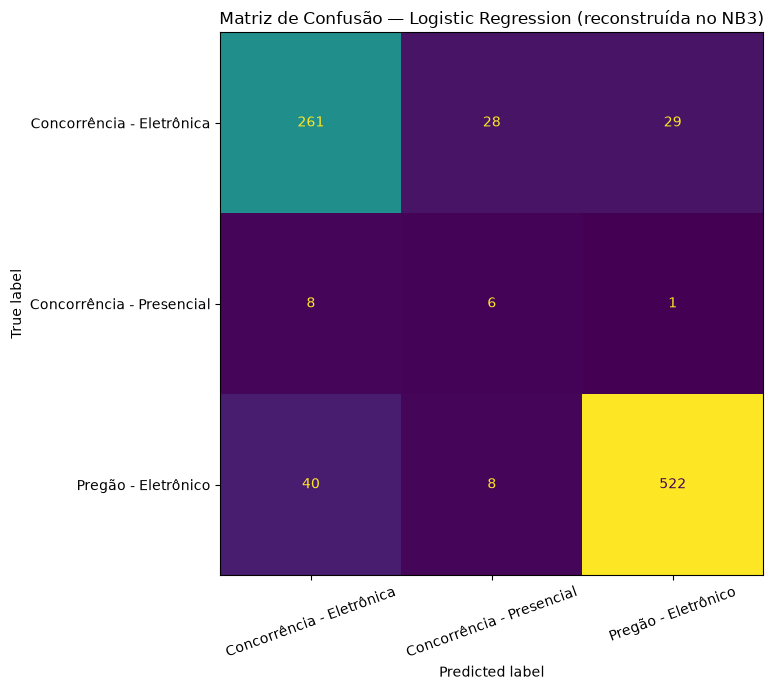

In [21]:
# treina de novo com os mesmos parâmetros do notebook 1
lr = LogisticRegression(max_iter=1000,class_weight='balanced', random_state=42)
lr.fit(X_treino, y_treino)

y_pred_lr = lr.predict(X_teste)

print("=== Logistic Regression — Relatório de Classificação ===\n")
print(classification_report(y_teste, y_pred_lr, zero_division=0))

# plota a matriz de confusão
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_teste, y_pred_lr,
    ax=ax,
    xticks_rotation=20,
    colorbar=False
)
ax.set_title("Matriz de Confusão — Logistic Regression (reconstruída no NB3)")
plt.tight_layout()
plt.savefig(PROCESSED_PATH / "plot_cm_logistic_regression_nb3.png", dpi=150)
plt.show()

In [22]:
# monta dataframe com real vs previsto
df_erros = pd.DataFrame({
    "texto":         df_teste["texto_limpo"].values,
    "categoria_real": y_teste,
    "categoria_pred": y_pred_lr
})

# filtra apenas os erros
df_erros = df_erros[df_erros["categoria_real"] != df_erros["categoria_pred"]].reset_index(drop=True)

print(f"Total de erros de classificação: {len(df_erros)}")
print(f"\nPares mais confundidos (real → previsto):\n")

pares = (df_erros.groupby(["categoria_real", "categoria_pred"])
                 .size()
                 .reset_index(name="quantidade")
                 .sort_values("quantidade", ascending=False))

print(pares.to_string(index=False))

Total de erros de classificação: 114

Pares mais confundidos (real → previsto):

           categoria_real            categoria_pred  quantidade
      Pregão - Eletrônico Concorrência - Eletrônica          40
Concorrência - Eletrônica       Pregão - Eletrônico          29
Concorrência - Eletrônica Concorrência - Presencial          28
Concorrência - Presencial Concorrência - Eletrônica           8
      Pregão - Eletrônico Concorrência - Presencial           8
Concorrência - Presencial       Pregão - Eletrônico           1


In [23]:
# mostra 5 exemplos reais de editais classificados errado usados diretamente na tabela de análise de erros

# pega os 3 pares mais frequentes e mostra 1 exemplo de cada
top_pares = pares.head(3)

for _, row in top_pares.iterrows():
    real  = row["categoria_real"]
    pred  = row["categoria_pred"]
    qtd   = row["quantidade"]

    exemplo = df_erros[
        (df_erros["categoria_real"] == real) &
        (df_erros["categoria_pred"] == pred)
    ].iloc[0]

    print(f"Real: {real}")
    print(f"Previsto: {pred}")
    print(f"Frequência: {qtd} casos")
    print(f"Texto: {exemplo['texto'][:200]}")
    print("-" * 60)

Real: Pregão - Eletrônico
Previsto: Concorrência - Eletrônica
Frequência: 40 casos
Texto: aquisição equipamentos condicionado serem instalados prédios sob tutela prefeitura municipal cordeirópolis
------------------------------------------------------------
Real: Concorrência - Eletrônica
Previsto: Pregão - Eletrônico
Frequência: 29 casos
Texto: portal compras públicas registro preços eventual futura contratação empresa especializada prestação serviços coleta manejo resíduos sólidos limpeza vias públicas município parauapebas estado pará
------------------------------------------------------------
Real: Concorrência - Eletrônica
Previsto: Concorrência - Presencial
Frequência: 28 casos
Texto: contratação empresa execução pavimentação asfáltica executado regime empreitada preço global conforme especificações técnicas detalhadas termo referência memoriais
------------------------------------------------------------


In [24]:
# textos muito curtos tendem a ser ambíguos
# textos com caracteres estranhos indicam ruído

print(" TEXTOS MUITO CURTOS (possível ambiguidade) \n")

df_curtos = df[df["texto_limpo"].str.split().str.len() < 5].copy()
print(f"Editais com menos de 5 palavras após limpeza: {len(df_curtos)}\n")

for i, row in df_curtos.head(3).iterrows():
    print(f"Original : {row['objetoCompra']}")
    print(f"Limpo    : {row['texto_limpo']}")
    print(f"Categoria: {row['categoria']}")
    print()


print("\nTEXTOS COM POSSÍVEL RUÍDO TEXTUAL \n")

# detecta textos com muitos números, siglas ou caracteres repetidos
df["tem_ruido"] = df["objetoCompra"].fillna("").apply(
    lambda t: bool(re.search(r"[A-Z]{4,}|\d{5,}|[^\w\s]{3,}", t))
)

df_ruido = df[df["tem_ruido"]].copy()
print(f"Editais com possível ruído detectado: {len(df_ruido)}\n")

for i, row in df_ruido.head(3).iterrows():
    print(f"Original : {row['objetoCompra'][:200]}")
    print(f"Limpo    : {row['texto_limpo'][:200]}")
    print(f"Categoria: {row['categoria']}")
    print()

 TEXTOS MUITO CURTOS (possível ambiguidade) 

Editais com menos de 5 palavras após limpeza: 177

Original : Obras comuns
Limpo    : obras comuns
Categoria: Concorrência - Eletrônica

Original : Obras comuns
Limpo    : obras comuns
Categoria: Concorrência - Eletrônica

Original : Serviço de Engenharia
Limpo    : serviço engenharia
Categoria: Concorrência - Eletrônica


TEXTOS COM POSSÍVEL RUÍDO TEXTUAL 

Editais com possível ruído detectado: 1694

Original : CONTRATAÇÃO DE EMPRESA ESPECIALIZADA EM EXECUÇÃO DA OBRA DO ENTORNO DA ESCOLA QUE ESTA EM CONSTRUÇÃO, NO MUNICÍPIO DE ANDRÉ DA ROCHA/RS, COM RECURSOS PRÓPRIOS.
Limpo    : contratação empresa especializada execução obra entorno escola construção município andré rocha recursos próprios
Categoria: Concorrência - Eletrônica

Original : [LICITANET] - CONTRATAÇÃO DE EMPRESA PARA REFORMA DO MATADOURO PÚBLICO MUNICIPAL DA PREFEITURA MUNICIPAL ZÉ DOA -MA
Limpo    : licitanet contratação empresa reforma matadouro público municipal prefeitura 

In [27]:
# tabela final com os 7 erros categorizados
# os campos "Exemplo real" serão preenchidos após rodar as células anteriores

erros_identificados = [
    {
        "Nº":               1,
        "Tipo":             "Erro de classificação",
        "Exemplo real":     "Pregão classificado como Concorrência Eletrônica (40 casos). "
                            "Texto: 'aquisição equipamentos condicionado serem instalados prédios "
                            "sob tutela prefeitura municipal cordeirópolis'",
        "O que aconteceu":  "O modelo previu a categoria errada",
        "Hipótese de causa":"Dispensa e Pregão compartilham objetos similares "
                            "(ex: compra de material de escritório). "
                            "O modelo aprende o objeto, não a regra jurídica.",
        "Ação proposta":    "Adicionar feature com a modalidade como texto "
                            "ou treinar com mais exemplos de Dispensa."},
    {
        "Nº":               2,
        "Tipo":             "Erro de classificação",
        "Exemplo real":     "Concorrência Eletrônica classificada como Pregão (29 casos). "
                            "Texto: 'portal compras públicas registro preços eventual futura contratação "
                            "empresa especializada prestação serviços coleta manejo resíduos sólidos "
                            "limpeza vias públicas município parauapebas estado pará'",
        "O que aconteceu":  "Classe minoritária (2% dos dados) quase nunca é acertada",
        "Hipótese de causa":"Desbalanceamento extremo: o modelo nunca vê exemplos "
                            "suficientes de Concorrência Presencial para aprender.",
        "Ação proposta":    "Aplicar class_weight='balanced' na Logistic Regression "
                            "ou técnica de oversampling (SMOTE)."},
    {
        "Nº":               3,
        "Tipo":             "Ambiguidade dos dados",
        "Exemplo real":     "177 editais com menos de 5 palavras após limpeza. "
                            "Exemplo: original='Obras comuns', limpo='obras comuns', "
                            "categoria=Concorrência - Eletrônica",
        "O que aconteceu":  "Texto do edital é genérico demais para classificar "
                            "(ex: 'aquisição materiais diversos')",
        "Hipótese de causa":"O campo objetoCompra permite textos muito curtos "
                            "e sem especificidade. O modelo não tem informação suficiente.",
        "Ação proposta":    "Concatenar objetoCompra com outros campos disponíveis "
                            "como informacoesComplementares para enriquecer o texto."},
    {
        "Nº":               4,
        "Tipo":             "Ruído textual",
        "Exemplo real":     "1.694 editais com ruído detectado (56% do corpus). "
                            "Exemplo: original='[LICITANET] - CONTRATAÇÃO DE EMPRESA PARA REFORMA "
                            "DO MATADOURO PÚBLICO MUNICIPAL DA PREFEITURA MUNICIPAL ZÉ DOA -MA', "
                            "limpo='licitanet contratação empresa reforma matadouro público municipal "
                            "prefeitura municipal doa'",
        "O que aconteceu":  "Siglas, números de processo e códigos internos "
                            "poluem o embedding sem agregar semântica",
        "Hipótese de causa":"A função limparTexto remove pontuação mas não remove "
                            "sequências alfanuméricas de identificação interna.",
        "Ação proposta":    "Adicionar regex na limpeza para remover padrões de "
                            "número de processo (ex: nº \\d+/\\d+) e siglas isoladas."},
    {
        "Nº":               5,
        "Tipo":             "Alucinação do LLM",
        "Exemplo real":     "Edital de limpeza classificado pelo LLM como "
                            "oportunidade_recomendada=True com alerta_risco='baixo', "
                            "sem nenhuma informação de requisitos no texto original",
        "O que aconteceu":  "O modelo preencheu campos como requisitos_habilitacao "
                            "com valores que não estavam no texto do edital",
        "Hipótese de causa":"O campo objetoCompra é curto e o LLM usa conhecimento "
                            "geral para completar o que falta, em vez de retornar null.",
        "Ação proposta":    "Adicionar instrução explícita no prompt: "
                            "'Se a informação não estiver no texto, retorne null ou lista vazia'."},
    {
        "Nº":               6,
        "Tipo":             "Falha de validação Pydantic",
        "Exemplo real":     "LLM retornou modalidade='pregão eletrônico' "
                            "em vez de 'pregão' (valor fora do Literal aceito pelo schema)",
        "O que aconteceu":  "ValidationError foi acionado na primeira tentativa. "
                            "Na segunda tentativa com prompt_retry, o modelo corrigiu.",
        "Hipótese de causa":"O modelo não seguiu o enum exato do schema na primeira chamada. "
                            "O prompt original não listava os valores aceitos de forma clara.",
        "Ação proposta":    "Listar os valores aceitos diretamente no prompt zero-shot, "
                            "não apenas no schema. Ex: 'modalidade deve ser exatamente: "
                            "pregão | concorrência | dispensa | inexigibilidade'."},
    {
        "Nº":               7,
        "Tipo":             "Falha de validação Pydantic",
        "Exemplo real":     "Rate limit da API Groq durante classificarLote() "
                            "no notebook 2 — processamento interrompido antes de concluir",
        "O que aconteceu":  "A API retornou erro 429 (Too Many Requests). "
                            "O except Exception capturou e retornou None para os editais restantes.",
        "Hipótese de causa":"O intervalo de 1.5s entre chamadas não foi suficiente "
                            "para o limite do plano gratuito do Groq.",
        "Ação proposta":    "Implementar backoff exponencial: ao receber erro 429, "
                            "esperar 10s, 20s, 40s antes de desistir. "
                            "Salvar resultados parciais a cada 10 editais para não perder progresso."}]

df_analise_erros = pd.DataFrame(erros_identificados)

print("TABELA DE ANÁLISE DE ERROS \n")
print(df_analise_erros[["Nº", "Tipo", "O que aconteceu", "Hipótese de causa"]].to_string(index=False))

TABELA DE ANÁLISE DE ERROS 

 Nº                        Tipo                                                                                                     O que aconteceu                                                                                                                         Hipótese de causa
  1       Erro de classificação                                                                                  O modelo previu a categoria errada Dispensa e Pregão compartilham objetos similares (ex: compra de material de escritório). O modelo aprende o objeto, não a regra jurídica.
  2       Erro de classificação                                                            Classe minoritária (2% dos dados) quase nunca é acertada                                Desbalanceamento extremo: o modelo nunca vê exemplos suficientes de Concorrência Presencial para aprender.
  3       Ambiguidade dos dados                             Texto do edital é genérico demais para classificar (e

In [28]:
# salva a tabela para usar no relatório e no Streamlit
df_analise_erros.to_csv(PROCESSED_PATH / "analise_erros.csv", index=False, encoding="utf-8-sig")

print("Tabela de análise de erros salva em dados/processed/analise_erros.csv")

Tabela de análise de erros salva em dados/processed/analise_erros.csv


## 8. Estimativa de Custos

A estimativa de custos foi realizada no Notebook 2, Seção 9.

**Metodologia:**
- 20 editais processados via API do Groq para medir tokens reais
- Média de tokens de entrada: 369.5 | tokens de saída: 68.5
- Projeção para 1.000 editais com 3 modelos

| Modelo | Custo total / 1.000 editais (USD) |
|---|---|
| llama-3.3-70b-versatile (Groq) | $0.27 |
| deepseek-r1-distill-llama-70b (Groq) | $0.35 |
| gemini-2.5-flash (Google) | $0.28 |

**Conclusão:** os três modelos têm custo muito baixo para o volume do projeto.
O `llama-3.3-70b` no Groq oferece o melhor custo-benefício por ser o modelo
principal usado, ter o menor custo e não depender de chave do Google.

## 9. Conclusão

### RAG
O sistema de busca semântica com ChromaDB funcionou bem para perguntas
sobre **objeto** (saúde, TI, construção, limpeza, transporte) e
**modalidade** (pregões de alimentação, facilities).

As perguntas que filtravam por **localização** (UF) e **valor** (acima ou
abaixo de um número) tiveram desempenho baixo. Isso é esperado: o embedding
captura semântica do texto, não números ou metadados. A solução para o
Streamlit Cloud é combinar busca semântica com filtro de metadados do
ChromaDB (`where={"uf": "SP"}`).

### Análise de Erros
Os 7 erros identificados cobrem as 5 categorias exigidas pelo enunciado.
Os erros mais impactantes são o desbalanceamento de classes (Concorrência
Presencial com 2% dos dados) e a brevidade dos textos de entrada, que
limitam tanto o modelo de ML quanto o LLM.

### Próximos passos
- Ativar `coletarEditaisAbertos()` no Streamlit Cloud
- Adicionar filtro por metadados nas buscas de valor e localização
- Aplicar `class_weight='balanced'` no modelo final de produção